In [1]:
import io
import pandas as pd

!pip install liac-arff -q
import arff

  Preparing metadata (setup.py) ... done


In [2]:
ruta_archivo = '/content/sample_data/chronic_kidney_disease.arff'

In [4]:
import pandas as pd


ruta_archivo = "/content/sample_data/chronic_kidney_disease.arff"

# Nombres oficiales de las 25 columnas del dataset renal
columnas = [
    "age",
    "bp",
    "sg",
    "al",
    "su",
    "rbc",
    "pc",
    "pcc",
    "ba",
    "bgr",
    "bu",
    "sc",
    "sod",
    "pot",
    "hemo",
    "pcv",
    "wbcc",
    "rbcc",
    "htn",
    "dm",
    "cad",
    "appet",
    "pe",
    "ane",
    "class",
]


try:
    df = pd.read_csv(
        ruta_archivo,
        skiprows=29,
        header=None,
        names=columnas,
        na_values="?",
        skipinitialspace=True,
        on_bad_lines="skip",
    )
    print("¡Archivo cargado con éxito!")
    print(
        f"Dimensiones finales: {df.shape[0]} filas y {df.shape[1]} columnas."
    )


    print("\nVista previa de los datos:")
    print(df.head())

except FileNotFoundError:
    print(
        f"Error: No se encontró el archivo en la ruta '{ruta_archivo}'. "
        "Revisa si termina en '.arff' o '.txt' en tu panel izquierdo."
    )
except Exception as e:
    print(f"Ocurrió un error inesperado al leer el archivo: {e}")

¡Archivo cargado con éxito!
Dimensiones finales: 397 filas y 25 columnas.

Vista previa de los datos:
    age    bp     sg   al   su     rbc        pc         pcc          ba  \
0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

     bgr  ...  pcv  wbcc  rbcc  htn   dm cad appet   pe  ane class  
0  121.0  ...   44  7800   5.2  yes  yes  no  good   no   no   ckd  
1    NaN  ...   38  6000   NaN   no   no  no  good   no   no   ckd  
2  423.0  ...   31  7500   NaN   no  yes  no  poor   no  yes   ckd  
3  117.0  ...   32  6700   3.9  yes   no  no  poor  yes  yes   ckd  
4  106.0  ...   35  7300   4.6   no   no  no  good   no   no   ckd  

[5 rows x 25 columns]


In [3]:
import os
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats


SEED = 42
INK = '#2b2b2b'
TEAL = '#2f6b76'
OCHRE = '#c0852f'
BRICK = '#a4503e'
STEM = '#b9b0a2'
PANEL = '#f7f3ec'
GRIDC = '#ded6c8'

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'font.size': 10,
    'font.family': 'serif',
    'figure.facecolor': 'white',
    'axes.facecolor': PANEL,
    'axes.edgecolor': '#9a9486',
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.titlelocation': 'left',
    'axes.titlepad': 8,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': INK,
    'ytick.color': INK
})


def grid_h(ax):
    ax.set_axisbelow(True)
    ax.grid(axis='y', color=GRIDC, linewidth=0.7)
    ax.grid(axis='x', visible=False)


ruta_archivo = '/content/sample_data/chronic_kidney_disease.arff'

if not os.path.exists(ruta_archivo):
    print(f"Archivo no encontrado en {ruta_archivo}. Descargándolo desde tu repositorio de GitHub...")
    os.makedirs(os.path.dirname(ruta_archivo), exist_ok=True)
    url_directa = 'https://raw.githubusercontent.com/treicimedina/Enfermedad-Renal/main/chronic_kidney_disease.arff'
    try:
        urllib.request.urlretrieve(url_directa, ruta_archivo)
        print("¡Descarga completada con éxito!")
    except Exception as e:
        raise FileNotFoundError(f"No se pudo descargar el archivo automáticamente de GitHub: {e}")

columnas = []
datos = []
leyendo_datos = False

with open(ruta_archivo, 'r', encoding='utf-8') as f:
    for line in f:
        line_clean = line.strip()
        if not line_clean or line_clean.startswith('%'):
            continue

        if line_clean.lower().startswith('@attribute'):
            parts = line_clean.split()
            col_name = parts[1].strip("'\"")
            columnas.append(col_name)

        elif line_clean.lower().startswith('@data'):
            leyendo_datos = True
            continue

        if leyendo_datos:
            fila = [celda.strip() for celda in line_clean.split(',')]
            if len(fila) == len(columnas):
                datos.append(fila)

df = pd.DataFrame(datos, columns=columnas)

n = len(df)
z = stats.norm.ppf(0.975)

C_TARGET = 'class'
C_HTN = 'htn'
C_HEMO = 'hemo'
C_PCV = 'pcv'
C_UREA = 'bu'
C_CREAT = 'sc'

print('Filas y columnas del dataset renal (Cargado con éxito):', df.shape)

Filas y columnas del dataset renal (Cargado con éxito): (397, 25)


In [5]:
import numpy as np
import pandas as pd

z = 1.96

def classic_ci(x):
    x = pd.to_numeric(x, errors='coerce').dropna().values
    m = x.mean()
    se = x.std(ddof=1) / np.sqrt(len(x))
    return m, m - z * se, m + z * se, len(x)

S1 = {}

columnas_dataset = [
    ('age', 'Edad'),
    ('bp', 'Pres.Art'),
    ('bgr', 'Glucemia')
]

for col, name in columnas_dataset:
    m, lo, hi, nn = classic_ci(df[col])
    S1[col] = (m, lo, hi, nn)
    print(f'{name:8s}: media={m:,.3f}  IC clásico 95% [{lo:,.3f}, {hi:,.3f}]  (n={nn:,})')

Edad    : media=51.456  IC clásico 95% [49.751, 53.161]  (n=388)
Pres.Art: media=76.468  IC clásico 95% [75.098, 77.837]  (n=385)
Glucemia: media=147.864  IC clásico 95% [139.605, 156.124]  (n=354)


In [6]:
import numpy as np
import pandas as pd
import scipy.stats as stats

SEED = 42
rng = np.random.default_rng(SEED)

def boot_mean(x, B=10000, batch=200):
    x = pd.to_numeric(x, errors='coerce').dropna().values
    nn = len(x)
    reps = np.empty(B)
    done = 0
    while done < B:
        b = min(batch, B - done)
        idx = rng.integers(0, nn, size=(b, nn))
        reps[done:done+b] = x[idx].mean(axis=1)
        done += b
    return x, reps

def bca_ci(x, reps, theta, alpha=0.05):
    z0 = stats.norm.ppf(np.mean(reps < theta))
    S = x.sum()
    nn = len(x)
    jack = (S - x) / (nn - 1)
    diff = jack.mean() - jack
    a = (diff**3).sum() / (6.0 * ((diff**2).sum())**1.5)
    zl, zu = stats.norm.ppf(alpha/2), stats.norm.ppf(1 - alpha/2)
    a1 = stats.norm.cdf(z0 + (z0 + zl) / (1 - a * (z0 + zl)))
    a2 = stats.norm.cdf(z0 + (z0 + zu) / (1 - a * (z0 + zu)))
    return np.percentile(reps, 100 * a1), np.percentile(reps, 100 * a2), z0, a

boot = {}

columnas_dataset = [
    ('age', 'Edad'),
    ('bp', 'Pres.Art'),
    ('bgr', 'Glucemia')
]

for col, name in columnas_dataset:
    m, clo, chi, nn = S1[col]


    x, reps = boot_mean(df[col])
    plo, phi = np.percentile(reps, [2.5, 97.5])
    blo, bhi, z0, a = bca_ci(x, reps, m)

    boot[col] = (reps, m, (clo, chi), (plo, phi), (blo, bhi), name)

    print(f'{name:8s}  media={m:,.3f}   (z0={z0:+.3f}, a={a:+.4f})')
    print(f'   clásico   [{clo:,.3f}, {chi:,.3f}]')
    print(f'   percentil [{plo:,.3f}, {phi:,.3f}]')
    print(f'   BCa       [{blo:,.3f}, {bhi:,.3f}]')

Edad      media=51.456   (z0=+0.005, a=-0.0057)
   clásico   [49.751, 53.161]
   percentil [49.719, 53.116]
   BCa       [49.709, 53.109]
Pres.Art  media=76.468   (z0=+0.016, a=+0.0136)
   clásico   [75.098, 77.837]
   percentil [75.143, 77.845]
   BCa       [75.169, 77.922]
Glucemia  media=147.864   (z0=+0.014, a=+0.0178)
   clásico   [139.605, 156.124]
   percentil [139.842, 156.562]
   BCa       [140.257, 157.022]


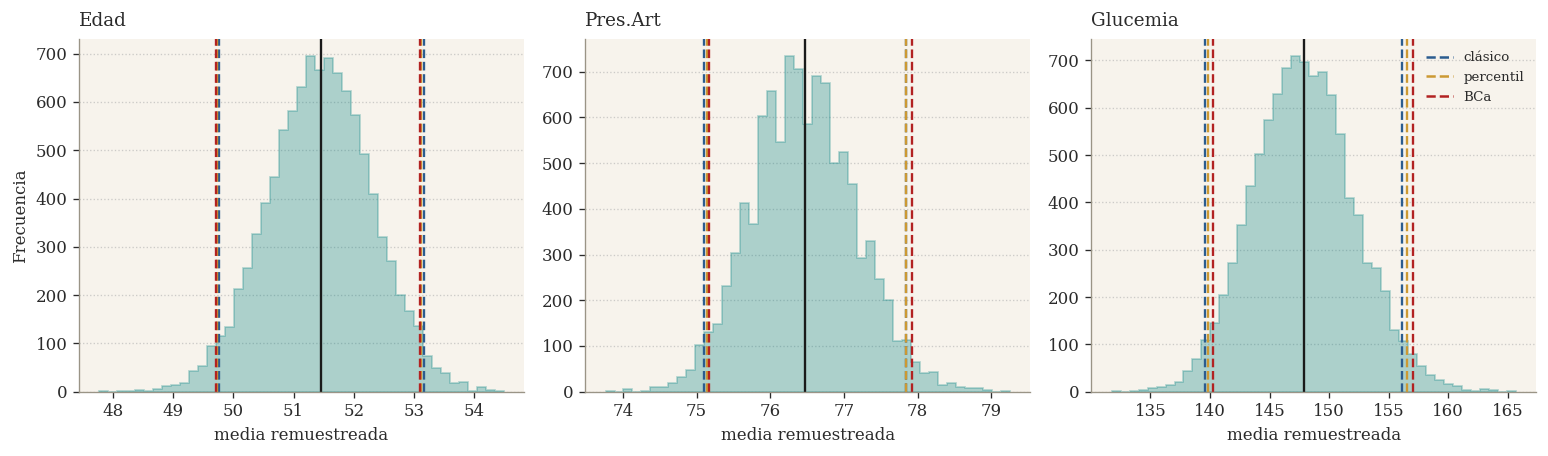

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


TEAL = '#008080'
STEM = '#2b5c8f'
OCHRE = '#cc9933'
BRICK = '#b22222'
INK = '#1a1a1a'


def grid_h(ax):
    ax.grid(True, axis='y', linestyle=':', alpha=0.6)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.9))

columnas_grafico = ['age', 'bp', 'bgr']

for a, col in zip(ax, columnas_grafico):
    reps, m, (clo, chi), (plo, phi), (blo, bhi), name = boot[col]

    a.hist(reps, bins=45, color=TEAL, alpha=0.30, edgecolor=TEAL,
           linewidth=1.0, histtype='stepfilled', zorder=2)

    for (lo, hi), col_ in [((clo, chi), STEM), ((plo, phi), OCHRE), ((blo, bhi), BRICK)]:
        a.axvline(lo, color=col_, lw=1.4, ls='--')
        a.axvline(hi, color=col_, lw=1.4, ls='--')


    a.axvline(m, color=INK, lw=1.4)

    a.set_title(name)
    a.set_xlabel('media remuestreada')
    grid_h(a)

ax[0].set_ylabel('Frecuencia')


leg = [
    Line2D([0], [0], color=STEM, ls='--', label='clásico'),
    Line2D([0], [0], color=OCHRE, ls='--', label='percentil'),
    Line2D([0], [0], color=BRICK, ls='--', label='BCa')
]
ax[2].legend(handles=leg, fontsize=8, frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig('fig_bootstrap.png', bbox_inches='tight')
plt.show()

In [8]:
import numpy as np
import pandas as pd


SEED = 42
rng = np.random.default_rng(SEED)


df_clean = df.copy()
df_clean['age'] = pd.to_numeric(df_clean['age'], errors='coerce')
df_clean = df_clean.dropna(subset=['age', 'class'])
df_clean = df_clean[df_clean['class'].isin(['ckd', 'notckd'])]

age = df_clean['age'].values
lab = (df_clean['class'] == 'ckd').values

n = len(age)
n1 = int(lab.sum())  # Cantidad de pacientes con CKD
n0 = n - n1          # Cantidad de pacientes sin CKD
tot = age.sum()

obs = age[lab == 1].mean() - age[lab == 0].mean()

B = 10000
perm = np.empty(B)

for j in range(B):
    idx = rng.choice(n, size=n1, replace=False)
    s1 = age[idx].sum()
    perm[j] = s1 / n1 - (tot - s1) / n0

pval = (np.sum(np.abs(perm) >= abs(obs)) + 1) / (B + 1)

print(f'Diferencia observada = {obs:.3f} años (CKD - No CKD)')
print(f'Distribución nula: rango [{perm.min():.3f}, {perm.max():.3f}], sd={perm.std():.3f}')
print(f'p de permutación = {pval:.5f}')

Diferencia observada = 8.180 años (CKD - No CKD)
Distribución nula: rango [-7.206, 6.898], sd=1.786
p de permutación = 0.00010


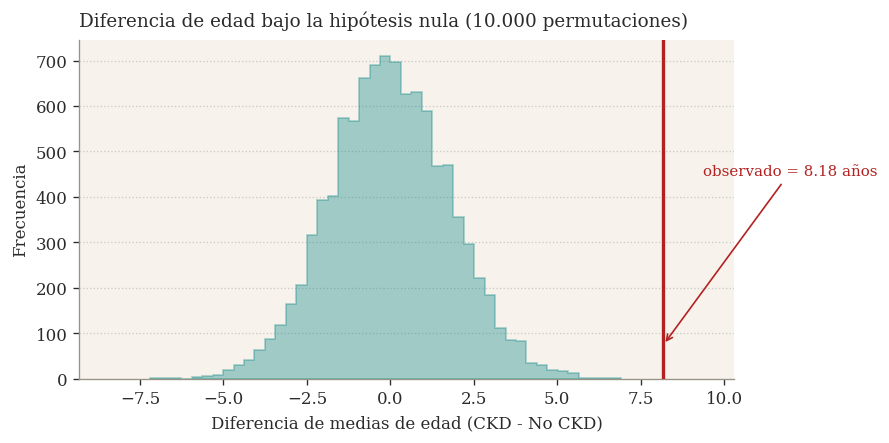

In [9]:
import matplotlib.pyplot as plt

TEAL = '#008080'
BRICK = '#b22222'

def grid_h(ax):
    ax.grid(True, axis='y', linestyle=':', alpha=0.6)

fig, ax = plt.subplots(figsize=(7.5, 3.8))

ax.hist(perm, bins=45, color=TEAL, alpha=0.35, edgecolor=TEAL,
        linewidth=1.0, histtype='stepfilled', zorder=2)

ax.axvline(obs, color=BRICK, lw=2.0, zorder=3)

max_y = ax.get_ylim()[1]

offset_x = 1.2 if obs > 0 else -6.5

ax.annotate(f'observado = {obs:.2f} años',
            xy=(obs, max_y * 0.1),
            xytext=(obs + offset_x, max_y * 0.6),
            color=BRICK, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=BRICK))

padding = (perm.max() - perm.min()) * 0.15
ax.set_xlim(min(perm.min(), obs) - padding, max(perm.max(), obs) + padding)

ax.set_title('Diferencia de edad bajo la hipótesis nula (10.000 permutaciones)')
ax.set_xlabel('Diferencia de medias de edad (CKD - No CKD)')
ax.set_ylabel('Frecuencia')

grid_h(ax)

plt.tight_layout()
plt.savefig('fig_permutacion.png', bbox_inches='tight')
plt.show()

In [10]:
import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)

pairs = [
    ('age', 'bp', 'Edad vs Presión Arterial'),
    ('bgr', 'bu', 'Glucemia vs Urea en Sangre'),
    ('sc', 'sod', 'Creatinina vs Sodio'),
    ('hemo', 'pcv', 'Hemoglobina vs Vol. Celular (PCV)'),
    ('age', 'bgr', 'Edad vs Glucemia')
]

res = []

for c1, c2, lbl in pairs:
    s = df[[c1, c2]].copy()
    s[c1] = pd.to_numeric(s[c1], errors='coerce')
    s[c2] = pd.to_numeric(s[c2], errors='coerce')


    s = s.dropna().values
    x, y = s[:, 0], s[:, 1]
    m = len(x)


    r0 = np.corrcoef(x, y)[0, 1]

    Bc = 3000
    rs = np.empty(Bc)
    for j in range(Bc):
        idx = rng.integers(0, m, m)
        rs[j] = np.corrcoef(x[idx], y[idx])[0, 1]


    lo, hi = np.percentile(rs, [2.5, 97.5])


    estado = 'inestable' if (lo < 0) != (hi < 0) else 'robusta'
    res.append((lbl, r0, lo, hi, estado))

    print(f'{lbl:36s} r={r0:+.3f}  IC95=[{lo:+.3f}, {hi:+.3f}]  {estado}')


print("\n(Referencia - Intento de Artefacto):")

df_artefacto = df[['hemo', 'pcv']].copy()

df_artefacto['hemo'] = pd.to_numeric(df_artefacto['hemo'], errors='coerce').fillna(999)
df_artefacto['pcv'] = pd.to_numeric(df_artefacto['pcv'], errors='coerce').fillna(999)

r_art = np.corrcoef(df_artefacto['hemo'], df_artefacto['pcv'])[0, 1]

print(f'Correlación Hemoglobina vs PCV usando códigos erróneos (999) = {r_art:.3f}  <- artefacto')

Edad vs Presión Arterial             r=+0.159  IC95=[+0.070, +0.251]  robusta
Glucemia vs Urea en Sangre           r=+0.146  IC95=[+0.066, +0.236]  robusta
Creatinina vs Sodio                  r=-0.690  IC95=[-0.881, -0.144]  robusta
Hemoglobina vs Vol. Celular (PCV)    r=+0.895  IC95=[+0.868, +0.919]  robusta
Edad vs Glucemia                     r=+0.256  IC95=[+0.172, +0.336]  robusta

(Referencia - Intento de Artefacto):
Correlación Hemoglobina vs PCV usando códigos erróneos (999) = 0.799  <- artefacto


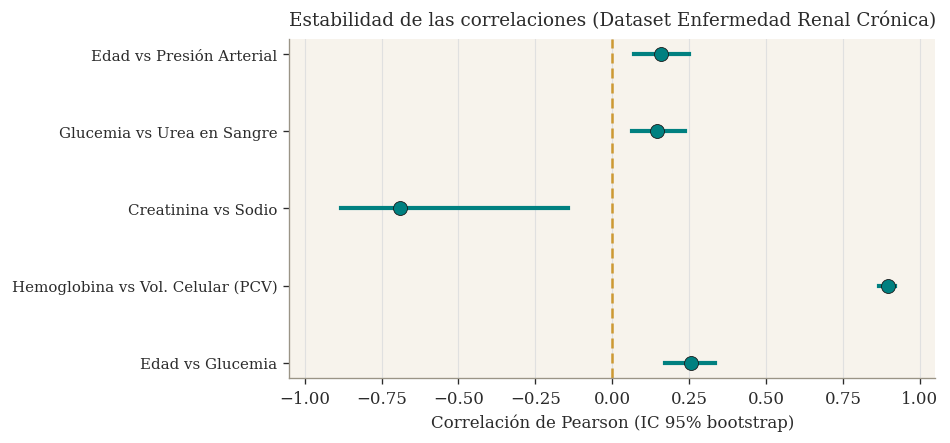

In [11]:
import numpy as np
import matplotlib.pyplot as plt

BRICK = '#b22222'
TEAL = '#008080'
OCHRE = '#cc9933'
INK = '#1a1a1a'
GRIDC = '#e0e0e0'

fig, ax = plt.subplots(figsize=(8, 3.8))


ylabs = [r[0] for r in res]
yy = np.arange(len(res))[::-1]

for (lbl, r0, lo, hi, estado), y in zip(res, yy):
    col = BRICK if estado == 'inestable' else TEAL
    ax.plot([lo, hi], [y, y], color=col, lw=2.5, zorder=2)
    ax.scatter(r0, y, color=col, s=70, zorder=3, edgecolor=INK, linewidth=0.5)

ax.axvline(0, color=OCHRE, ls=(0, (4, 2)), lw=1.5, zorder=1)

ax.set_yticks(yy)
ax.set_yticklabels(ylabs, fontsize=9)

ax.set_xlim(-1.05, 1.05)

ax.set_xlabel('Correlación de Pearson (IC 95% bootstrap)')
ax.set_title('Estabilidad de las correlaciones (Dataset Enfermedad Renal Crónica)')
ax.set_axisbelow(True)

ax.grid(axis='x', color=GRIDC, linewidth=0.7)
ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.savefig('fig_correlaciones.png', bbox_inches='tight')
plt.show()

In [12]:
import numpy as np
import pandas as pd


SEED = 42
rng = np.random.default_rng(SEED)


df_clean = df[['class', 'htn']].copy()
df_clean['class'] = df_clean['class'].astype(str).str.strip()
df_clean['htn'] = df_clean['htn'].astype(str).str.strip()

df_clean = df_clean[df_clean['class'].isin(['ckd', 'notckd']) & df_clean['htn'].isin(['yes', 'no'])]

q = (df_clean['class'] == 'ckd').sum() / len(df_clean)

ckd_group = df_clean[df_clean['class'] == 'ckd']
notckd_group = df_clean[df_clean['class'] == 'notckd']

p_con = (ckd_group['htn'] == 'yes').sum() / len(ckd_group)
p_sin = (notckd_group['htn'] == 'yes').sum() / len(notckd_group)

N = 1000
B = 10000

has_ckd = rng.random((B, N)) < q

dp = np.where(has_ckd, p_con, p_sin)

rate = (rng.random((B, N)) < dp).sum(axis=1) / N

teor = q * p_con + (1 - q) * p_sin

run = np.cumsum(rate) / np.arange(1, B + 1)
mcse = rate.std() / np.sqrt(B)

print(f'Proporción con Enfermedad Renal Crónica (CKD): q = {q:.4f}')
print(f'Probabilidad HTN dado CKD (p_con) = {p_con:.4f} | Dado No-CKD (p_sin) = {p_sin:.4f}')
print(f'Tasa esperada teórica de hipertensión global = {teor:.4f}')
print(f'Simulada: media = {rate.mean():.4f}, sd = {rate.std():.4f}')
print(f'Error estándar de Monte Carlo de la media = {mcse:.6f} ({mcse*100:.4f} puntos porcentuales)')
print(f'IC 95% de la tasa de hipertensión en la población = [{np.percentile(rate, 2.5):.4f}, {np.percentile(rate, 97.5):.4f}]')
print(f'Percentil 99 (peor escenario de prevalencia) = {np.percentile(rate, 99):.4f}')

umbral = 0.40
print(f'Probabilidad de superar el {umbral*100:.0f}% de hipertensión global = {np.mean(rate > umbral):.4f}')

Proporción con Enfermedad Renal Crónica (CKD): q = 0.6278
Probabilidad HTN dado CKD (p_con) = 0.5887 | Dado No-CKD (p_sin) = 0.0000
Tasa esperada teórica de hipertensión global = 0.3696
Simulada: media = 0.3696, sd = 0.0153
Error estándar de Monte Carlo de la media = 0.000153 (0.0153 puntos porcentuales)
IC 95% de la tasa de hipertensión en la población = [0.3400, 0.3990]
Percentil 99 (peor escenario de prevalencia) = 0.4060
Probabilidad de superar el 40% de hipertensión global = 0.0212


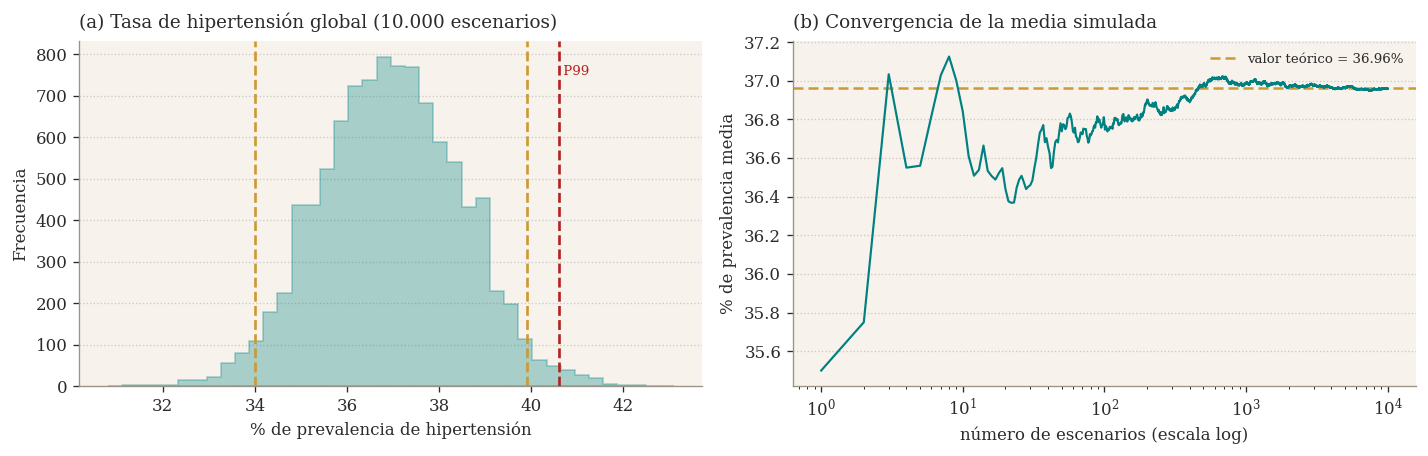

In [13]:
import numpy as np
import matplotlib.pyplot as plt

TEAL = '#008080'
OCHRE = '#cc9933'
BRICK = '#b22222'

def grid_h(ax):
    ax.grid(True, axis='y', linestyle=':', alpha=0.6)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.9))

p025, p975, p99 = np.percentile(rate, [2.5, 97.5, 99])

ax[0].hist(rate * 100, bins=40, color=TEAL, alpha=0.32, edgecolor=TEAL,
           linewidth=1.0, histtype='stepfilled', zorder=2)

for v, c in [(p025 * 100, OCHRE), (p975 * 100, OCHRE), (p99 * 100, BRICK)]:
    ax[0].axvline(v, color=c, ls='--', lw=1.6, zorder=3)

ax[0].set_title('(a) Tasa de hipertensión global (10.000 escenarios)')
ax[0].set_xlabel('% de prevalencia de hipertensión')
ax[0].set_ylabel('Frecuencia')
grid_h(ax[0])

ax[0].text(p99 * 100, ax[0].get_ylim()[1] * 0.9, ' P99', color=BRICK, fontsize=8)


ax[1].plot(np.arange(1, B + 1), run * 100, color=TEAL, lw=1.3, zorder=3)
ax[1].axhline(teor * 100, color=OCHRE, ls=(0, (4, 2)), lw=1.5, zorder=2,
             label=f'valor teórico = {teor*100:.2f}%')

ax[1].set_xscale('log')
ax[1].set_title('(b) Convergencia de la media simulada')
ax[1].set_xlabel('número de escenarios (escala log)')
ax[1].set_ylabel('% de prevalencia media')
grid_h(ax[1])
ax[1].legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig('fig_montecarlo.png', bbox_inches='tight')
plt.show()

In [14]:
import numpy as np

tamanos = [100, 500, 1000, 5000]
filas = []
dists = {}

for Nt in tamanos:
    rng = np.random.default_rng(SEED)

    de = rng.random((B, Nt)) < q

    dpp = np.where(de, p_con, p_sin)

    rt = (rng.random((B, Nt)) < dpp).sum(axis=1) / Nt
    dists[Nt] = rt

    lo, hi = np.percentile(rt, [2.5, 97.5])
    p99n = np.percentile(rt, 99)

    filas.append((Nt, rt.mean() * 100, lo * 100, hi * 100, (hi - lo) * 100, p99n * 100))

print(f"{'N':>6} {'media%':>8} {'IC95 inf%':>10} {'IC95 sup%':>10} {'ancho pp':>9} {'P99%':>7}")
for f in filas:
    print(f"{f[0]:>6} {f[1]:>8.2f} {f[2]:>10.1f} {f[3]:>10.1f} {f[4]:>9.1f} {f[5]:>7.1f}")

     N   media%  IC95 inf%  IC95 sup%  ancho pp    P99%
   100    36.99       28.0       47.0      19.0    48.0
   500    36.99       32.8       41.2       8.4    42.0
  1000    36.96       34.0       39.9       5.9    40.6
  5000    36.96       35.7       38.3       2.6    38.6


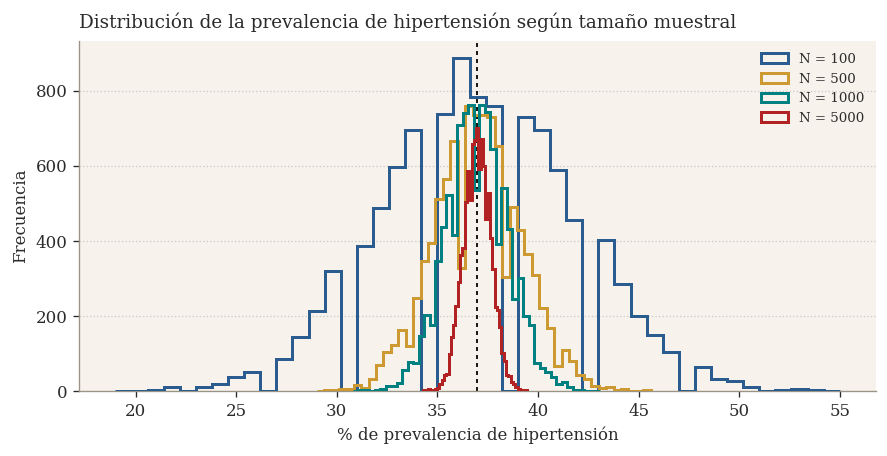

In [15]:
import matplotlib.pyplot as plt

STEM = '#2b5c8f'
OCHRE = '#cc9933'
TEAL = '#008080'
BRICK = '#b22222'
INK = '#1a1a1a'

def grid_h(ax):
    ax.grid(True, axis='y', linestyle=':', alpha=0.6)

fig, ax = plt.subplots(figsize=(7.5, 3.9))

cols = {100: STEM, 500: OCHRE, 1000: TEAL, 5000: BRICK}

for Nt in tamanos:
    ax.hist(dists[Nt] * 100, bins=45, histtype='step', linewidth=1.8,
            color=cols[Nt], label=f'N = {Nt}', zorder=3)


ax.axvline(teor * 100, color=INK, ls=(0, (2, 2)), lw=1.2, zorder=2)

ax.set_title('Distribución de la prevalencia de hipertensión según tamaño muestral')
ax.set_xlabel('% de prevalencia de hipertensión')
ax.set_ylabel('Frecuencia')

grid_h(ax)
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig('fig_montecarlo_N.png', bbox_inches='tight')
plt.show()

In [16]:
import numpy as np
import pandas as pd
import scipy.stats as stats


bu_data = pd.to_numeric(df['bu'].astype(str).str.strip(), errors='coerce').dropna().values

full = bu_data.mean()
med = np.median(bu_data)
trim5 = stats.trim_mean(bu_data, 0.05)

excl = bu_data[bu_data <= np.percentile(bu_data, 99)].mean()

S = bu_data.sum()
nn = len(bu_data)
jack = (S - bu_data) / (nn - 1)
jse = np.sqrt((nn - 1) / nn * ((jack - jack.mean()) ** 2).sum())

print('Media de la Urea en Sangre (bu)')
print(f'  completa      = {full:,.2f}')
print(f'  recortada 5%  = {trim5:,.2f}')
print(f'  sin top 1%    = {excl:,.2f}')
print(f'  mediana       = {med:,.2f}')
print(f'  jackknife SE  = {jse:,.2f}  (observación más influyente = {bu_data.max():,.0f})')

Media de la Urea en Sangre (bu)
  completa      = 57.61
  recortada 5%  = 51.21
  sin top 1%    = 54.85
  mediana       = 42.00
  jackknife SE  = 2.61  (observación más influyente = 391)


In [17]:
import numpy as np
import pandas as pd
import scipy.stats as stats

SEED = 42
rng = np.random.default_rng(SEED)

df_artefacto = df[['hemo', 'pcv']].copy()

hemo_art = pd.to_numeric(df_artefacto['hemo'], errors='coerce').fillna(999)
pcv_art = pd.to_numeric(df_artefacto['pcv'], errors='coerce').fillna(999)
r_cod = np.corrcoef(hemo_art, pcv_art)[0, 1]

df_limpio = df[['hemo', 'pcv']].copy()
df_limpio['hemo'] = pd.to_numeric(df_limpio['hemo'], errors='coerce')
df_limpio['pcv'] = pd.to_numeric(df_limpio['pcv'], errors='coerce')
df_limpio = df_limpio.dropna()
r_lim = np.corrcoef(df_limpio['hemo'], df_limpio['pcv'])[0, 1]

print('Correlación entre Hemoglobina y Volumen Celular (PCV)')
print(f'  con códigos de error erróneos (999)  : r = {r_cod:+.3f}  (artefacto)')
print(f'  excluyendo/limpiando esos datos      : r = {r_lim:+.3f}  (valor real, fuerte)')

df_cc = df[['sc', 'bu']].copy()
df_cc['sc'] = pd.to_numeric(df_cc['sc'], errors='coerce')
df_cc['bu'] = pd.to_numeric(df_cc['bu'], errors='coerce')
s = df_cc.dropna().values

x, y = s[:, 0], s[:, 1]  # x = Creatinina, y = Urea
r_full = np.corrcoef(x, y)[0, 1]

mask = (x <= 5) & (y <= 150)
xt, yt = x[mask], y[mask]
r_trim = np.corrcoef(xt, yt)[0, 1]

m = len(xt)
rs = np.empty(3000)
for j in range(3000):
    idx = rng.integers(0, m, m)
    rs[j] = np.corrcoef(xt[idx], yt[idx])[0, 1]
lo, hi = np.percentile(rs, [2.5, 97.5])

print('\nCorrelación Creatinina vs Urea en Sangre')
print(f'  con todos los datos (incluyendo outliers) : r = {r_full:+.3f}')
print(f'  sin outliers (sc<=5, bu<=150, {mask.sum():,} filas): r = {r_trim:+.3f}  IC95=[{lo:+.3f}, {hi:+.3f}]')

df2 = df.drop_duplicates().copy()

df2['age'] = pd.to_numeric(df2['age'], errors='coerce')
df2['class'] = df2['class'].astype(str).str.strip()

g1 = df2.loc[df2['class'] == 'ckd', 'age'].dropna()
g0 = df2.loc[df2['class'] == 'notckd', 'age'].dropna()

t, p = stats.ttest_ind(g1, g0, equal_var=False)

print(f'\nDiferencia de edad sin duplicados ({len(df2):,} filas totales):')
print(f'  Diferencia observada = {g1.mean() - g0.mean():.2f} años (CKD - No CKD)')
print(f'  t-test estadística   = {t:.2f}')
print(f'  p-valor calculado    = {p:.5e}  (significativo p < 0.001)')

Correlación entre Hemoglobina y Volumen Celular (PCV)
  con códigos de error erróneos (999)  : r = +0.799  (artefacto)
  excluyendo/limpiando esos datos      : r = +0.895  (valor real, fuerte)

Correlación Creatinina vs Urea en Sangre
  con todos los datos (incluyendo outliers) : r = +0.586
  sin outliers (sc<=5, bu<=150, 319 filas): r = +0.718  IC95=[+0.658, +0.766]

Diferencia de edad sin duplicados (397 filas totales):
  Diferencia observada = 8.30 años (CKD - No CKD)
  t-test estadística   = 4.89
  p-valor calculado    = 1.56662e-06  (significativo p < 0.001)


In [18]:
import os

print('Figuras generadas:', sorted(f for f in os.listdir('.') if f.startswith('fig_') and f.endswith('.png')))

Figuras generadas: ['fig_bootstrap.png', 'fig_correlaciones.png', 'fig_montecarlo.png', 'fig_montecarlo_N.png', 'fig_permutacion.png']


In [19]:
import os
import urllib.request
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

SEED = 42
rng = np.random.default_rng(SEED)

INK = '#2b2b2b'
TEAL = '#2f6b76'
OCHRE = '#c0852f'
BRICK = '#a4503e'
STEM = '#b9b0a2'
PANEL = '#f7f3ec'
GRIDC = '#ded6c8'

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'font.size': 10,
    'font.family': 'serif',
    'figure.facecolor': 'white',
    'axes.facecolor': PANEL,
    'axes.edgecolor': '#9a9486',
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.titlelocation': 'left',
    'axes.titlepad': 8,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': INK,
    'ytick.color': INK
})


def grid_h(ax):
    ax.set_axisbelow(True)
    ax.grid(axis='y', color=GRIDC, lw=0.7)
    ax.grid(axis='x', visible=False)


ruta_archivo = '/content/sample_data/chronic_kidney_disease.arff'

if not os.path.exists(ruta_archivo):
    print(f"Archivo no encontrado en {ruta_archivo}. Descargándolo desde tu repositorio de GitHub...")
    os.makedirs(os.path.dirname(ruta_archivo), exist_ok=True)
    url_directa = 'https://raw.githubusercontent.com/treicimedina/Enfermedad-Renal/main/chronic_kidney_disease.arff'
    try:
        urllib.request.urlretrieve(url_directa, ruta_archivo)
        print("¡Descarga completada con éxito!")
    except Exception as e:
        raise FileNotFoundError(f"No se pudo descargar el archivo de GitHub: {e}")

columnas = []
datos = []
leyendo_datos = False

with open(ruta_archivo, 'r', encoding='utf-8') as f:
    for line in f:
        line_clean = line.strip()
        if not line_clean or line_clean.startswith('%'):
            continue
        if line_clean.lower().startswith('@attribute'):
            parts = line_clean.split()
            col_name = parts[1].strip("'\"")
            columnas.append(col_name)
        elif line_clean.lower().startswith('@data'):
            leyendo_datos = True
            continue
        if leyendo_datos:
            fila = [celda.strip() for celda in line_clean.split(',')]
            if len(fila) == len(columnas):
                datos.append(fila)

df = pd.DataFrame(datos, columns=columnas)

df['class'] = df['class'].astype(str).str.strip()

df['target_numeric'] = df['class'].map({'ckd': 1, 'notckd': 0})

TARGET = 'target_numeric'

C_HEMO = 'hemo'
C_PCV = 'pcv'
C_UREA = 'bu'
C_CREAT = 'sc'
C_HTN = 'htn'

print('Filas y columnas cargadas:', df.shape)
print('Distribución de la variable objetivo (TARGET):')
print(df['class'].value_counts())

Filas y columnas cargadas: (397, 26)
Distribución de la variable objetivo (TARGET):
class
ckd       248
notckd    149
Name: count, dtype: int64


In [20]:
df_prep = df.copy()

variables_numericas = ['age', 'bu', 'sc', 'hemo', 'pcv']
for col in variables_numericas:
    df_prep[col] = pd.to_numeric(df_prep[col], errors='coerce')

df_prep = df_prep[df_prep['age'] > 0].copy()

for c in ['bu', 'sc']:
    limite_superior = df_prep[c].quantile(0.99)
    df_prep[c] = df_prep[c].clip(upper=limite_superior)

nan_hemo = int(df_prep['hemo'].isna().sum())
nan_pcv = int(df_prep['pcv'].isna().sum())

print(f"Filas tras filtrar edad: {len(df_prep)}")
print(f"Faltantes -> Hemoglobina: {nan_hemo} | Volumen Celular (PCV): {nan_pcv}")

Filas tras filtrar edad: 388
Faltantes -> Hemoglobina: 50 | Volumen Celular (PCV): 67


In [21]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

df_imp = df.copy()
cols_clinicas = ['hemo', 'pcv', 'bu', 'sc', 'age']
for col in cols_clinicas:
    df_imp[col] = pd.to_numeric(df_imp[col], errors='coerce')

pred_hemo = ['bu', 'sc', 'age']
pred_pcv = ['age', 'hemo']

todas_las_variables = list(set(['hemo', 'pcv'] + pred_hemo + pred_pcv))
comp = df_imp.dropna(subset=todas_las_variables).copy()

print('Correlaciones clínicas que justifican los predictores (limpias de NaNs):')
print('  Hemoglobina vs ', {p: round(np.corrcoef(comp['hemo'], comp[p])[0, 1], 3) for p in pred_hemo})
print('  Vol. Celular vs', {p: round(np.corrcoef(comp['pcv'], comp[p])[0, 1], 3) for p in pred_pcv})

lm_hemo = LinearRegression().fit(comp[pred_hemo], comp['hemo'])
lm_pcv = LinearRegression().fit(comp[pred_pcv], comp['pcv'])

pred = lm_hemo.predict(comp[pred_hemo])
resid = comp['hemo'].values - pred

print(f'\nAjuste Hemoglobina: R2={lm_hemo.score(comp[pred_hemo], comp.hemo):.4f} | Vol. Celular (PCV): R2={lm_pcv.score(comp[pred_pcv], comp.pcv):.4f}')
print('\nVerificación de supuestos (regresión de Hemoglobina):')
print(f'  residuos: media={resid.mean():.4f}, sd={resid.std():.4f}, asimetría={stats.skew(resid):.2f}')
print(f'  corr(residuo, ajustado)={np.corrcoef(resid, pred)[0, 1]:.3f} -> linealidad en media OK; residuos NO normales')

variabilidad_reducida = (1 - pred.std() / comp['hemo'].std()) * 100
print(f'  encogimiento: sd(observado)={comp.hemo.std():.2f} vs sd(imputado)={pred.std():.2f} ({variabilidad_reducida:.1f}% menos)')
print(f'  valores faltantes listos para imputar: Hemoglobina={int(df_imp.hemo.isna().sum())}, Vol. Celular (PCV)={int(df_imp.pcv.isna().sum())}')

Correlaciones clínicas que justifican los predictores (limpias de NaNs):
  Hemoglobina vs  {'bu': np.float64(-0.613), 'sc': np.float64(-0.395), 'age': np.float64(-0.224)}
  Vol. Celular vs {'age': np.float64(-0.255), 'hemo': np.float64(0.892)}

Ajuste Hemoglobina: R2=0.3868 | Vol. Celular (PCV): R2=0.7986

Verificación de supuestos (regresión de Hemoglobina):
  residuos: media=-0.0000, sd=2.2428, asimetría=-0.13
  corr(residuo, ajustado)=0.000 -> linealidad en media OK; residuos NO normales
  encogimiento: sd(observado)=2.87 vs sd(imputado)=1.78 (37.9% menos)
  valores faltantes listos para imputar: Hemoglobina=52, Vol. Celular (PCV)=70


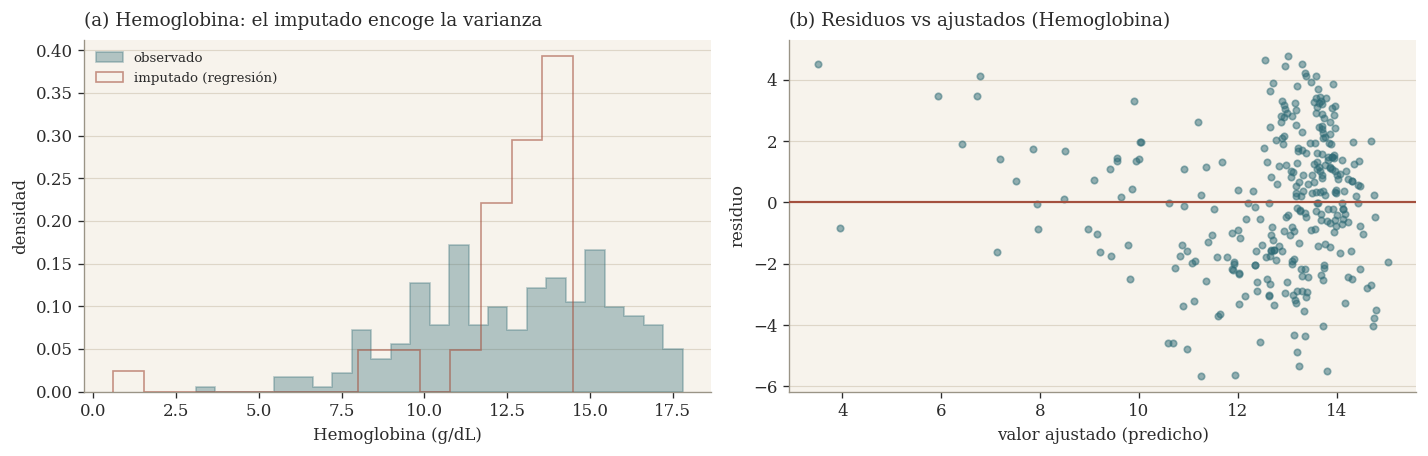

In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(12, 3.9))

obs = comp['hemo']

df_faltante_hemo = df_imp[df_imp['hemo'].isna() & df_imp[pred_hemo].notna().all(axis=1)]

imp = lm_hemo.predict(df_faltante_hemo[pred_hemo])

ax[0].hist(obs, bins=25, color=TEAL, alpha=0.35, histtype='stepfilled',
           edgecolor=TEAL, lw=1, density=True, label='observado', zorder=2)

ax[0].hist(imp, bins=15, color=BRICK, alpha=0.6, histtype='step',
           lw=1.9, density=True, label='imputado (regresión)', zorder=3)

ax[0].set_title('(a) Hemoglobina: el imputado encoge la varianza')
ax[0].set_xlabel('Hemoglobina (g/dL)')
ax[0].set_ylabel('densidad')
grid_h(ax[0])
ax[0].legend(fontsize=8, frameon=False)

ax[1].scatter(pred, resid, s=15, color=TEAL, alpha=0.5, zorder=2)
ax[1].axhline(0, color=BRICK, lw=1.3, zorder=3)

ax[1].set_title('(b) Residuos vs ajustados (Hemoglobina)')
ax[1].set_xlabel('valor ajustado (predicho)')
ax[1].set_ylabel('residuo')
grid_h(ax[1])

plt.tight_layout()
plt.savefig('fig_imputacion.png', bbox_inches='tight')
plt.show()

In [24]:
import numpy as np
import pandas as pd

df_estudio = df.copy()
cols_estudio = ['hemo', 'bu', 'sc', 'age']
for col in cols_estudio:
    df_estudio[col] = pd.to_numeric(df_estudio[col], errors='coerce')

df_estudio['target_numeric'] = df_estudio['class'].astype(str).str.strip().map({'ckd': 1, 'notckd': 0})
TARGET = 'target_numeric'

df_del = df_estudio.dropna(subset=['hemo']).copy()

df_simple = df_estudio.copy()
mediana_hemo = df_simple['hemo'].median()
df_simple['hemo'] = df_simple['hemo'].fillna(mediana_hemo)

df_reg = df_estudio.copy()
mask_imputables = df_reg['hemo'].isna() & df_reg[pred_hemo].notna().all(axis=1)

predicciones_hemo = lm_hemo.predict(df_reg.loc[mask_imputables, pred_hemo])
df_reg.loc[mask_imputables, 'hemo'] = predicciones_hemo

df_reg['hemo'] = df_reg['hemo'].fillna(mediana_hemo)

tab = []
for nombre, d in [('Eliminación', df_del),
                  ('Imputación simple', df_simple),
                  ('Imputación regresión', df_reg)]:

    d_limpio = d.dropna(subset=[TARGET])

    n_final = len(d_limpio)
    media = d_limpio['hemo'].mean()
    mediana = d_limpio['hemo'].median()
    desviacion = d_limpio['hemo'].std()

    correlacion = np.corrcoef(d_limpio['hemo'], d_limpio[TARGET])[0, 1]

    tab.append([nombre, n_final, media, mediana, desviacion, correlacion])

df_comparativa = pd.DataFrame(
    tab,
    columns=['Estrategia', 'n', 'Media Hemo', 'Mediana Hemo', 'Desv. Estándar', 'Corr con Target']
).set_index('Estrategia')

print(df_comparativa.round(3))

                        n  Media Hemo  Mediana Hemo  Desv. Estándar  \
Estrategia                                                            
Eliminación           345      12.521          12.6           2.918   
Imputación simple     397      12.531          12.6           2.719   
Imputación regresión  397      12.527          12.7           2.827   

                      Corr con Target  
Estrategia                             
Eliminación                    -0.774  
Imputación simple              -0.732  
Imputación regresión           -0.720  


In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURES = ['hemo', 'pcv', 'bu', 'sc', 'age']

short = {
    'hemo': 'Hemoglobina',
    'pcv': 'Vol_Celular_PCV',
    'bu': 'Urea_Sangre',
    'sc': 'Creatinina_Serica',
    'age': 'Edad'
}

df_ml = df_reg.copy()

for col in FEATURES:
    df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

for col in FEATURES:
    mediana_col = df_ml[col].median()
    df_ml[col] = df_ml[col].fillna(mediana_col)

X = df_ml[FEATURES].values
y = df_ml[TARGET].values

y = y.astype(int)

Xtr, Xte, ytr, yte = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

sc = StandardScaler().fit(Xtr)
Xtr_s = sc.transform(Xtr)
Xte_s = sc.transform(Xte)

print(f'Entrenamiento (train) = {len(ytr):,} pacientes (Enfermedad Renal: {ytr.mean() * 100:.2f}%)')
print(f'Prueba (test)         = {len(yte):,} pacientes (Enfermedad Renal: {yte.mean() * 100:.2f}%)')

Entrenamiento (train) = 277 pacientes (Enfermedad Renal: 62.45%)
Prueba (test)         = 120 pacientes (Enfermedad Renal: 62.50%)


In [26]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

rem = list(range(len(FEATURES)))
sel = []
traj = []

while rem:
    best = None
    for c in rem:

        f = sm.Logit(ytr, sm.add_constant(Xtr_s[:, sel + [c]])).fit(disp=0, maxiter=200)

        if best is None or f.aic < best[0]:
            best = (f.aic, f.bic, c)

    sel.append(best[2])
    rem.remove(best[2])

    traj.append([len(sel), short[FEATURES[best[2]]], best[0], best[1]])

df_trayectoria = pd.DataFrame(traj, columns=['paso', 'variable', 'AIC', 'BIC']).set_index('paso')
print(df_trayectoria.round(1))

print(f'\nPenalización BIC por variable = ln(n) = {np.log(len(ytr)):.1f}')

               variable    AIC    BIC
paso                                 
1           Hemoglobina  131.4  138.6
2       Vol_Celular_PCV  105.7  116.6
3     Creatinina_Serica   91.6  106.1
4           Urea_Sangre   88.4  106.5
5                  Edad   90.1  111.8

Penalización BIC por variable = ln(n) = 5.6


In [27]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

def fit_eval(idx, name):
    m = LogisticRegression(
        penalty=None, max_iter=2000, class_weight='balanced', random_state=SEED
    ).fit(Xtr_s[:, idx], ytr)

    pte = m.predict_proba(Xte_s[:, idx])[:, 1]
    ptr = m.predict_proba(Xtr_s[:, idx])[:, 1]
    yhat = (pte >= 0.5).astype(int)

    return {
        'name': name,
        'idx': idx,
        'model': m,
        'auc_tr': roc_auc_score(ytr, ptr),
        'auc': roc_auc_score(yte, pte),
        'acc': accuracy_score(yte, yhat),
        'prec': precision_score(yte, yhat),
        'rec': recall_score(yte, yhat),
        'f1': f1_score(yte, yhat),
        'pte': pte,
        'yhat': yhat,
        'yhat_tr': (ptr >= 0.5).astype(int),
    }

idx1 = [FEATURES.index(c) for c in ['age', 'bu', 'sc']]

idx2 = list(range(len(FEATURES)))

idx3 = [FEATURES.index(c) for c in ['hemo', 'pcv', 'age']]

M1 = fit_eval(idx1, 'M1 (dominio fisiológico)')
M2 = fit_eval(idx2, 'M2 (completo)')
M3 = fit_eval(idx3, 'M3 (reducido/hematología)')

cvk = StratifiedKFold(5, shuffle=True, random_state=SEED)

for M in [M1, M2, M3]:
    cv = cross_val_score(
        LogisticRegression(
            penalty=None, max_iter=3000, class_weight='balanced', random_state=SEED
        ),
        Xtr_s[:, M['idx']],
        ytr,
        cv=cvk,
        scoring='roc_auc',
    )
    M['cv'] = cv.mean()
    M['cv_sd'] = cv.std()

print('M1 (fisiológico):', [short[FEATURES[i]] for i in idx1])
print('M2 (completo):   ', [short[FEATURES[i]] for i in idx2])
print(
    'M3 (reducido):   ',
    [short[FEATURES[i]] for i in idx3],
    '(descarta marcadores químicos de urea y creatinina)',
)

perf = pd.DataFrame(
    [
        [
            M['name'],
            len(M['idx']),
            M['auc_tr'],
            M['auc'],
            f"{M['cv']:.3f}+/-{M['cv_sd']:.3f}",
            M['acc'],
            M['prec'],
            M['rec'],
            M['f1'],
        ]
        for M in [M1, M2, M3]
    ],
    columns=[
        'Modelo',
        'n_vars',
        'AUC_tr',
        'AUC_test',
        'CV_AUC',
        'Acc',
        'Prec',
        'Recall',
        'F1',
    ],
).set_index('Modelo')

print('\n', perf.to_string())

best = M2
print('\nModelo final de referencia:', best['name'])

M1 (fisiológico): ['Edad', 'Urea_Sangre', 'Creatinina_Serica']
M2 (completo):    ['Hemoglobina', 'Vol_Celular_PCV', 'Urea_Sangre', 'Creatinina_Serica', 'Edad']
M3 (reducido):    ['Hemoglobina', 'Vol_Celular_PCV', 'Edad'] (descarta marcadores químicos de urea y creatinina)

                            n_vars    AUC_tr  AUC_test         CV_AUC       Acc      Prec    Recall        F1
Modelo                                                                                                      
M1 (dominio fisiológico)        3  0.915129  0.942815  0.917+/-0.025  0.891667  1.000000  0.826667  0.905109
M2 (completo)                   5  0.984660  0.991407  0.988+/-0.015  0.958333  0.986111  0.946667  0.965986
M3 (reducido/hematología)       3  0.978101  0.976000  0.980+/-0.022  0.941667  0.959459  0.946667  0.953020

Modelo final de referencia: M2 (completo)


In [28]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression

idxb = best['idx']

sm_fit = sm.Logit(ytr, sm.add_constant(Xtr_s[:, idxb])).fit(disp=0, maxiter=300)

names_b = ['const'] + [short[FEATURES[i]] for i in idxb]

B = 500
ntr = len(ytr)
boot = np.zeros((B, len(idxb) + 1))
Xtr_b = Xtr_s[:, idxb]

for b in range(B):

    ii = rng.integers(0, ntr, ntr)

    mb = LogisticRegression(penalty=None, max_iter=1000).fit(Xtr_b[ii], ytr[ii])

    boot[b, 0] = mb.intercept_[0]
    boot[b, 1:] = mb.coef_[0]

ciw = sm_fit.conf_int()

rows = []
for i, nm in enumerate(names_b):
    cl, ch = np.percentile(boot[:, i], [2.5, 97.5])

    orb = np.exp(boot[:, i])
    ol, oh = np.percentile(orb, [2.5, 97.5])

    coef_analitico = sm_fit.params[i]
    or_analitico = np.exp(coef_analitico)

    estable = 'si' if (ol > 1) == (oh > 1) else 'REVISAR'

    rows.append([
        nm, coef_analitico, ciw[i, 0], ciw[i, 1],
        cl, ch, or_analitico, ol, oh, estable
    ])

df_estabilidad = pd.DataFrame(
    rows,
    columns=[
        'Variable', 'coef', 'coefWaldInf', 'coefWaldSup',
        'coefBootInf', 'coefBootSup', 'OR', 'ORbootInf',
        'ORbootSup', 'Estable'
    ]
).set_index('Variable')

print(df_estabilidad.round(3).to_string())

                     coef  coefWaldInf  coefWaldSup  coefBootInf  coefBootSup            OR  ORbootInf     ORbootSup  Estable
Variable                                                                                                                     
const               8.938        4.773       13.102        5.943       16.769  7.612692e+03    381.026  1.916677e+07       si
Hemoglobina        -3.569       -5.213       -1.925       -6.611       -2.479  2.800000e-02      0.001  8.400000e-02       si
Vol_Celular_PCV    -2.366       -3.939       -0.794       -4.953       -1.203  9.400000e-02      0.007  3.000000e-01       si
Urea_Sangre        -2.615       -4.701       -0.529       -5.663       -0.782  7.300000e-02      0.003  4.580000e-01       si
Creatinina_Serica  23.032        9.742       36.322       10.978       46.408  1.006090e+10  59491.521  1.430623e+20       si
Edad                0.175       -0.434        0.784       -0.662        1.022  1.191000e+00      0.516  2.780000e+00  

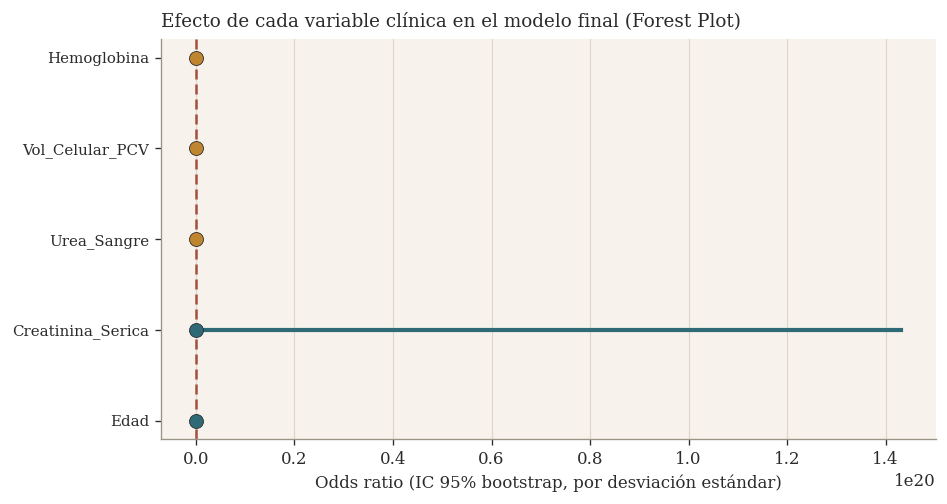

In [29]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 4.3))

rr = [r for r in rows if r[0] != 'const']
yy = np.arange(len(rr))[::-1]

for r, yv in zip(rr, yy):
    orr, lo, hi = r[6], r[7], r[8]

    col = TEAL if orr > 1 else OCHRE

    ax.plot([lo, hi], [yv, yv], color=col, lw=2.5, zorder=2)

    ax.scatter(orr, yv, color=col, s=70, edgecolor=INK, lw=0.5, zorder=3)

ax.axvline(1, color=BRICK, ls=(0, (4, 2)), lw=1.5, zorder=1)

ax.set_yticks(yy)
ax.set_yticklabels([r[0] for r in rr], fontsize=9)

ax.set_xlabel('Odds ratio (IC 95% bootstrap, por desviación estándar)')
ax.set_title('Efecto de cada variable clínica en el modelo final (Forest Plot)')

ax.set_axisbelow(True)
ax.grid(axis='x', color=GRIDC, lw=0.7)
ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.savefig('fig_bootstrap_or.png', bbox_inches='tight')
plt.show()

In [30]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

Xv = Xtr_s[:, idxb]

vif = pd.DataFrame({
    'Variable': [short[FEATURES[i]] for i in idxb],
    'VIF': [variance_inflation_factor(Xv, i) for i in range(len(idxb))]
}).set_index('Variable')

print("Análisis de Multicolinealidad (VIF):")
print(vif.round(2))

base = sm_fit.predict(sm.add_constant(Xv))

pr = (ytr - base) / np.sqrt(base * (1 - base))

residuos_extremos = int(np.sum(np.abs(pr) > 3))
porcentaje_extremos = np.mean(np.abs(pr) > 3) * 100

print(f'\nResiduos de Pearson extremos (|r| > 3): {residuos_extremos:,} de {len(pr):,} ({porcentaje_extremos:.2f}%)')

Análisis de Multicolinealidad (VIF):
                    VIF
Variable               
Hemoglobina        3.89
Vol_Celular_PCV    3.55
Urea_Sangre        1.98
Creatinina_Serica  1.47
Edad               1.07

Residuos de Pearson extremos (|r| > 3): 4 de 277 (1.44%)


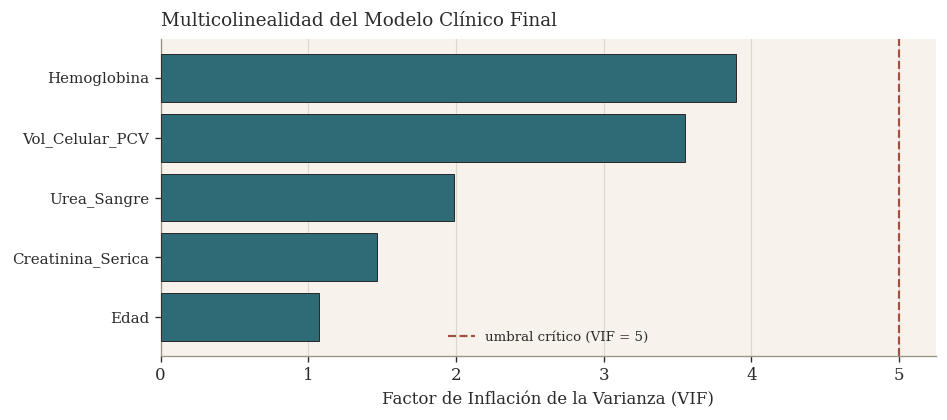

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.6))

vv = vif.sort_values('VIF')

ax.barh(
    range(len(vv)),
    vv['VIF'],
    color=TEAL,
    edgecolor=INK,
    lw=0.6,
    zorder=3
)

ax.axvline(
    5,
    color=BRICK,
    ls='--',
    lw=1.3,
    label='umbral crítico (VIF = 5)',
    zorder=2
)

ax.set_yticks(range(len(vv)))
ax.set_yticklabels(vv.index, fontsize=9)
ax.set_xlabel('Factor de Inflación de la Varianza (VIF)')
ax.set_title('Multicolinealidad del Modelo Clínico Final')

ax.set_axisbelow(True)
ax.grid(axis='x', color=GRIDC, lw=0.7)
ax.grid(axis='y', visible=False)
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig('fig_vif.png', bbox_inches='tight')
plt.show()

In [32]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score

yhat_tr = best['yhat_tr']
yhat_te = best['yhat']

cm_tr = confusion_matrix(ytr, yhat_tr)
cm_te = confusion_matrix(yte, yhat_te)

print('======================================================')
print('  MATRIZ DE CONFUSIÓN - ENTRENAMIENTO')
print('======================================================')
print(cm_tr)
print(f"  Exactitud (Acc) : {accuracy_score(ytr, yhat_tr):.3f}")
print(f"  Sensibilidad (Recall) : {recall_score(ytr, idxh_tr := yhat_tr):.3f}  <- clave para no omitir enfermos")
print(f"  Precisión (Prec)      : {precision_score(ytr, yhat_tr):.3f}")

print('\n======================================================')
print('  MATRIZ DE CONFUSIÓN - PRUEBA (VALIDACIÓN EXTERNA)')
print('======================================================')
print(cm_te)
print(f"  Exactitud (Acc) : {accuracy_score(yte, yhat_te):.3f}")
print(f"  Sensibilidad (Recall) : {recall_score(yte, yhat_te):.3f}  <- capacidad de detección real")
print(f"  Precisión (Prec)      : {precision_score(yte, yhat_te):.3f}")
print('======================================================')

  MATRIZ DE CONFUSIÓN - ENTRENAMIENTO
[[100   4]
 [ 12 161]]
  Exactitud (Acc) : 0.942
  Sensibilidad (Recall) : 0.931  <- clave para no omitir enfermos
  Precisión (Prec)      : 0.976

  MATRIZ DE CONFUSIÓN - PRUEBA (VALIDACIÓN EXTERNA)
[[44  1]
 [ 4 71]]
  Exactitud (Acc) : 0.958
  Sensibilidad (Recall) : 0.947  <- capacidad de detección real
  Precisión (Prec)      : 0.986


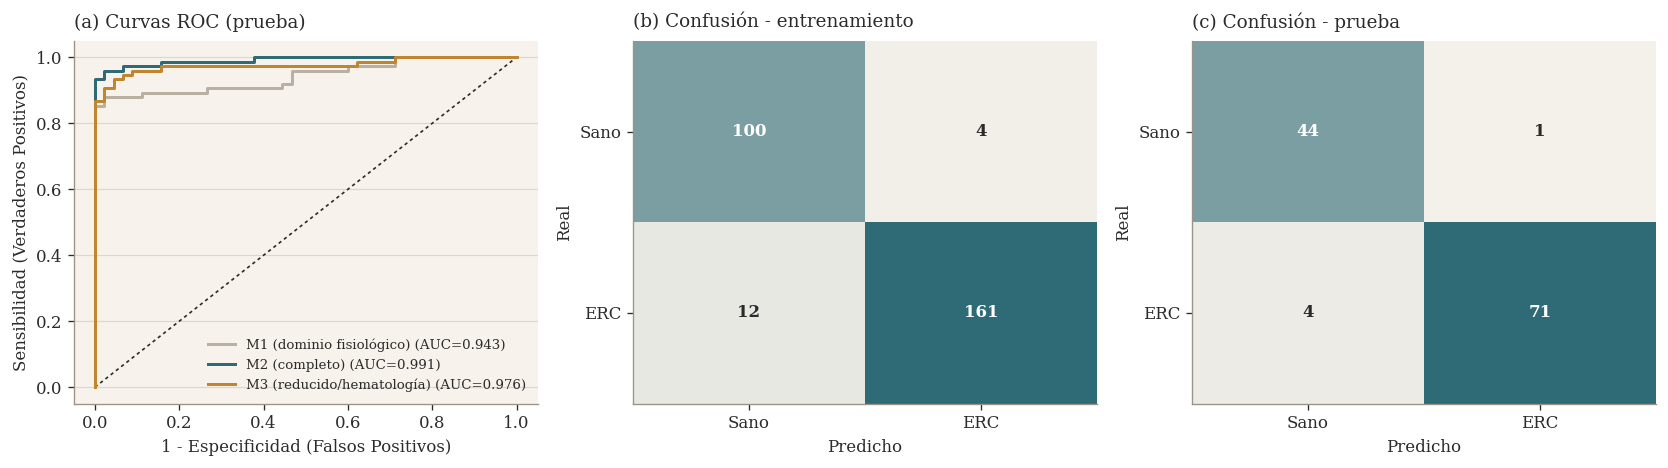

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_curve

cm_editorial = LinearSegmentedColormap.from_list('cm_editorial', [PANEL, TEAL])

fig, ax = plt.subplots(1, 3, figsize=(14, 4))

for M, c in [(M1, STEM), (M2, TEAL), (M3, OCHRE)]:
    fpr, tpr, _ = roc_curve(yte, M['pte'])
    ax[0].plot(
        fpr,
        tpr,
        color=c,
        lw=1.8,
        label=f"{M['name']} (AUC={M['auc']:.3f})",
        zorder=3
    )

ax[0].plot([0, 1], [0, 1], color=INK, ls=(0, (2, 2)), lw=1, zorder=2)
ax[0].set_title('(a) Curvas ROC (prueba)')
ax[0].set_xlabel('1 - Especificidad (Falsos Positivos)')
ax[0].set_ylabel('Sensibilidad (Verdaderos Positivos)')
grid_h(ax[0])
ax[0].legend(fontsize=8, frameon=False, loc='lower right')

matrices_confusion = [
    (ax[1], cm_tr, '(b) Confusión - entrenamiento'),
    (ax[2], cm_te, '(c) Confusión - prueba')
]

for a, cm, tt in matrices_confusion:
    vmax = cm.max()
    a.imshow(cm, cmap=cm_editorial, aspect='auto', vmin=0, vmax=vmax)

    for (i, j), v in np.ndenumerate(cm):
        txt_color = 'white' if v / vmax > 0.55 else INK
        a.text(
            j, i, f'{v:,}',
            ha='center', va='center',
            color=txt_color, fontsize=10, fontweight='bold'
        )

    a.set_xticks([0, 1])
    a.set_xticklabels(['Sano', 'ERC'])
    a.set_yticks([0, 1])
    a.set_yticklabels(['Sano', 'ERC'])

    a.set_xlabel('Predicho')
    a.set_ylabel('Real')
    a.set_title(tt)
    a.grid(False)

plt.tight_layout()
plt.savefig('fig_desempeno.png', bbox_inches='tight')
plt.show()

In [34]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

keyv = ['hemo', 'sc', 'age']
keyn = ['Hemoglobina', 'Creatinina', 'Edad']

rows = []

for nm, d in [
    ('Eliminación', df_del),
    ('Imputación simple', df_simple),
    ('Imputación regresión', df_reg),
]:

    d_clean = d.copy()

    for col in FEATURES:
        d_clean[col] = pd.to_numeric(d_clean[col], errors='coerce')

    for col in FEATURES:
        mediana_col = d_clean[col].median()
        d_clean[col] = d_clean[col].fillna(mediana_col)

    d_clean[TARGET] = pd.to_numeric(d_clean[TARGET], errors='coerce')
    d_clean = d_clean.dropna(subset=[TARGET])

    Xa = d_clean[FEATURES].values
    ya = d_clean[TARGET].values.astype(int)

    Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
        Xa, ya, test_size=0.30, random_state=SEED, stratify=ya
    )

    sca = StandardScaler().fit(Xa_tr)
    Xtr_scaled = sca.transform(Xa_tr)
    Xte_scaled = sca.transform(Xa_te)

    smf = sm.Logit(ya_tr, sm.add_constant(Xtr_scaled)).fit(
        disp=0, maxiter=300
    )
    ci = smf.conf_int()

    clf = LogisticRegression(
        penalty=None, max_iter=2000, class_weight='balanced', random_state=SEED
    ).fit(Xtr_scaled, ya_tr)
    probs_test = clf.predict_proba(Xte_scaled)[:, 1]
    au = roc_auc_score(ya_te, probs_test)

    r = [nm, len(ya_te), round(au, 3)]

    for kv in keyv:

        j = FEATURES.index(kv) + 1
        r.append(f'{smf.params[j]:+.3f} [{ci[j, 0]:+.3f}, {ci[j, 1]:+.3f}]')

    rows.append(r)

df_comparativa_final = pd.DataFrame(
    rows,
    columns=['Estrategia', 'n_test', 'AUC'] + [f'coef {n}' for n in keyn],
).set_index('Estrategia')

print(df_comparativa_final.to_string())

                      n_test    AUC         coef Hemoglobina             coef Creatinina                coef Edad
Estrategia                                                                                                       
Eliminación              104  0.992  -3.496 [-5.450, -1.542]  +28.687 [+11.559, +45.815]  -0.174 [-0.968, +0.621]
Imputación simple        120  0.993  -3.160 [-4.578, -1.742]  +23.257 [+10.062, +36.451]  +0.150 [-0.432, +0.731]
Imputación regresión     120  0.991  -3.569 [-5.213, -1.925]   +23.032 [+9.742, +36.322]  +0.175 [-0.434, +0.784]


In [35]:
import os

figuras_guardadas = sorted(
    f for f in os.listdir('.') if f.startswith('fig_') and f.endswith('.png')
)

print('Visualizaciones de diagnóstico clínico generadas con éxito:')
print('===============================================================')
for fig in figuras_guardadas:
    print(f' ➜  [Archivo]: {fig}')
print('===============================================================')
print(f'Total de figuras listas para reporte: {len(figuras_guardadas)}')

Visualizaciones de diagnóstico clínico generadas con éxito:
 ➜  [Archivo]: fig_bootstrap.png
 ➜  [Archivo]: fig_bootstrap_or.png
 ➜  [Archivo]: fig_correlaciones.png
 ➜  [Archivo]: fig_desempeno.png
 ➜  [Archivo]: fig_imputacion.png
 ➜  [Archivo]: fig_montecarlo.png
 ➜  [Archivo]: fig_montecarlo_N.png
 ➜  [Archivo]: fig_permutacion.png
 ➜  [Archivo]: fig_vif.png
Total de figuras listas para reporte: 9
